# Your Very First Machine Learning (ML) Model: Logistic Regression

Dataset: [College Student Placement Factors Dataset](https://www.kaggle.com/datasets/sahilislam007/college-student-placement-factors-dataset) (`data/college_student_placement_dataset.csv`)

In [2]:
# Import our libraries.

from IPython.display import display

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

!pip install statsmodels
import statsmodels.api as sm


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


## Constants

It is a good programming practice to use constants to avoid repetition errors and to save yourself the effort of retyping the expression by _centralizing_ semantically identical values.

`DATASET_PATH` identifies the path to the dataset being loaded and operated on. `RANDOM_STATE` makes otherwise random operations reproducible run after run. Keep whatever value you set it to unless you want slightly different results.

In [3]:
DATASET_PATH = '/workspaces/ds-fall-2025-wed-M.E.P./Week-07-Classification/data/college_student_placement_dataset.csv'
RANDOM_STATE = 45

## Preliminary Inspection

See what the raw file looks like!

In [4]:
# Look at the first 5 lines of theraw contents of the file first.

with open(DATASET_PATH, 'r') as file:
    for line_number in range(5):
        if line := file.readline():
            print(line)
        else:
            break # Stop; there are less than 5 lines.


College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement

CLG0030,107,6.61,6.28,8,No,8,8,4,No

CLG0061,97,5.52,5.37,8,No,7,8,0,No

CLG0036,109,5.36,5.83,9,No,3,1,1,No

CLG0055,122,5.47,5.75,6,Yes,1,6,1,No



## Preliminary Load

Load the data. This is not the final form of the data which will be used, but it’s a `DataFrame` for further inspection so we can decide what to do with it next.

In [5]:
# Load the dataset into a pandas dataframe.

df = pd.read_csv(DATASET_PATH)
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


## Null Values Check
Inspect which varibles may be good / not good for using as features based on null values. 


In [6]:
# Identify which columns have null values. 

df.columns[df.isnull().any()]

df.isnull().sum()


College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64

## Duplicate Rows Check
If so, remove the duplicates.

In [7]:
# Check to see if our data has any duplicate rows.

duplicate_rows = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_rows}")

df[df.duplicated()]

Number of duplicate rows: 0


,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement


Many clean… 😐

## Categorical Categories

What are the categories for the categorial-looking (i.e., non-numeric) columns?

In [8]:
# Identify non-numeric (categorical-looking) columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns
print("Categorical Columns:")
print(categorical_cols)

# Show unique categories for each categorical column
print("\n Categories for each categorical column:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


Categorical Columns:
Index(['College_ID', 'Internship_Experience', 'Placement'], dtype='object')

 Categories for each categorical column:

College_ID:
['CLG0030' 'CLG0061' 'CLG0036' 'CLG0055' 'CLG0004' 'CLG0015' 'CLG0071'
 'CLG0096' 'CLG0097' 'CLG0057' 'CLG0063' 'CLG0077' 'CLG0064' 'CLG0017'
 'CLG0053' 'CLG0040' 'CLG0070' 'CLG0050' 'CLG0068' 'CLG0072' 'CLG0034'
 'CLG0087' 'CLG0073' 'CLG0024' 'CLG0008' 'CLG0025' 'CLG0018' 'CLG0014'
 'CLG0006' 'CLG0082' 'CLG0090' 'CLG0075' 'CLG0094' 'CLG0089' 'CLG0016'
 'CLG0076' 'CLG0047' 'CLG0054' 'CLG0058' 'CLG0100' 'CLG0046' 'CLG0001'
 'CLG0041' 'CLG0093' 'CLG0027' 'CLG0062' 'CLG0081' 'CLG0028' 'CLG0020'
 'CLG0051' 'CLG0069' 'CLG0088' 'CLG0038' 'CLG0029' 'CLG0035' 'CLG0019'
 'CLG0005' 'CLG0026' 'CLG0066' 'CLG0045' 'CLG0043' 'CLG0074' 'CLG0048'
 'CLG0012' 'CLG0099' 'CLG0011' 'CLG0091' 'CLG0083' 'CLG0080' 'CLG0044'
 'CLG0059' 'CLG0031' 'CLG0039' 'CLG0065' 'CLG0079' 'CLG0095' 'CLG0085'
 'CLG0033' 'CLG0007' 'CLG0037' 'CLG0032' 'CLG0049' 'CLG0056' 'CLG00

## Feature Engineering

Non-numeric columns containing `'Yes'` and `'No'` do not work with logistic regression. Binary categories can be converted an integral type (`int`) with a value of 0 or 1.

In [15]:

df
# Find columns that contain 'Yes'/'No'
yes_no_cols = [col for col in df.columns if df[col].isin(['Yes', 'No']).any()]

print("Columns with Yes/No values:")
print(yes_no_cols)

# Convert 'Yes' to 1 and 'No' to 0
for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print("\nConverted 'Yes'/'No' columns to numeric (1/0).")

Columns with Yes/No values:
[]

Converted 'Yes'/'No' columns to numeric (1/0).


❔ When should you use this versus using `pd.get_dummies`?

# Visualization with `sns.pairplot`

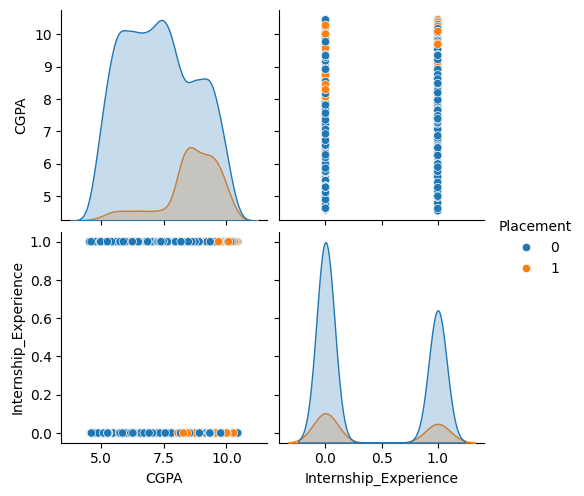

Index(['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed', 'Placement'],
      dtype='object')

In [19]:
#Note: Use pd.get_dummies() for non-binary (multi-class) categories

# Use sns.pariplot to visualize.

sns.pairplot(df[['CGPA', 'Internship_Experience', 'Placement']], hue='Placement')
plt.show()
df.columns

## Feature Selection 

Choose the columns corresponding to the features _IQ_ and _internship experience_ to be your `X`. Target _placement_ as your `y`.

In [20]:
# Set X to the desired features.
X = df[['IQ', 'Internship_Experience']]

# Set y to be our target variable. 
y = df['Placement']

# Check selection
print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
    IQ  Internship_Experience
0  107                      0
1   97                      0
2  109                      0
3  122                      1
4   96                      0

Target (y):
0    0
1    0
2    0
3    0
4    0
Name: Placement, dtype: int64


## Split to Testing and Training Datasets 

In [22]:
# Split our data into testing and training pairs.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Print the length and width of our testing data.
print('X_train: %d rows, %d columns' % X_train.shape)
print('X_test: %d rows, %d columns' % X_test.shape)
print('y_train: %d rows, 1 column' % y_train.shape)
print('y_test: %d rows, 1 column' % y_test.shape)

X_train: 8000 rows, 2 columns
X_test: 2000 rows, 2 columns
y_train: 8000 rows, 1 column
y_test: 2000 rows, 1 column


## Build and train your model

Initialize an empty Logistic Regression model, and then fit your model to your training data. 

In [24]:
# Initalize our logistic regressionmodel.
model = LogisticRegression()

# train the model on the training data
model.fit(X_train, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Evaluation

Make predictions with your test data and save the predictions as `y_pred`.

In [25]:
# 1. Make predictions of your test data and save them as `y_pred`. 

y_pred = model.predict(X_test)



Calculate and print the accuracy, precision, recall, and F1 scores of your model.

In [26]:
# 2. Calculate and print the accuracy, precision, recall, and F1 scores of your model.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the results 
print(f"Accuracy Score: {accuracy:.2f}" )
print(f"Precision Score: {precision:.2f}")
print(f"Recall Score   : {recall:.2f}")
print(f"F1 Score       : {f1:.2f}")

Accuracy Score: 0.83
Precision Score: 0.33
Recall Score   : 0.03
F1 Score       : 0.05


Plot a confusion matrix of your predicted results.

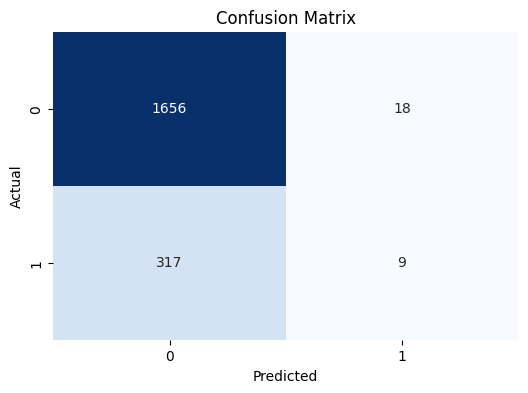

In [29]:
# 3. Plot a confusion matrix of your predicted results.

# confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


How many true positives and true negatives did your model get?

In [31]:
# How many true positives and true negatives did your model get?

true_negatives, false_positives, false_negatives, true_positives = conf_matrix.ravel()
print('True Negatives: %d' % true_negatives)
print('True Positives: %d' % true_positives)

True Negatives: 1656
True Positives: 9


Such awful 😞

# What is the Most Important Feature
 
Use `statsmodel` to create a summary report. Interpret the results.

In [33]:
# Add a constant term to the independent variables.
X_sm = sm.add_constant(X)  

# Fit the model.
logit_model = sm.Logit(y, X_sm)
result = logit_model.fit()

# Print the summary and interpret the results.
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.406531
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              Placement   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Tue, 21 Oct 2025   Pseudo R-squ.:                 0.09524
Time:                        15:10:14   Log-Likelihood:                -4065.3
converged:                       True   LL-Null:                       -4493.3
Covariance Type:            nonrobust   LLR p-value:                1.408e-186
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -7.4077      0.224    -33.142      0.000      -7.846      -6.

# Extra Credit: Use your brain and make a better model (as in better scores).



New Model Performance:
Accuracy : 0.90
Precision: 0.75
Recall   : 0.61
F1 Score : 0.67


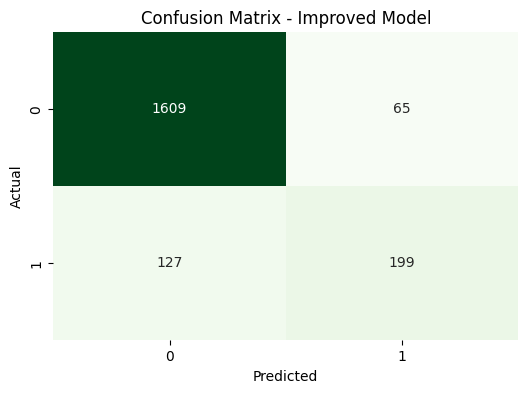

In [37]:
# Define the new X variable, and reuse the same y variable from before.

    # more features for a stronger model
X_new = df[['IQ', 'CGPA', 'Internship_Experience', 'Extra_Curricular_Score', 
            'Communication_Skills', 'Projects_Completed']]

    # Reuse the same y variable
y = df['Placement']

# Split our data into testing and training. Remember to use the same random state as you used before

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

# Initalize our model.
model_new = LogisticRegression(max_iter=1000)  # increase max_iter if needed


# Fit-train our model using our training data.
model_new.fit(X_train_new, y_train_new)

# Make new predicitions using our testing data. 
y_pred_new = model_new.predict(X_test_new)

# Print each of our scores to inspect performance.
accuracy_new = accuracy_score(y_test_new, y_pred_new)
precision_new = precision_score(y_test_new, y_pred_new)
recall_new = recall_score(y_test_new, y_pred_new)
f1_new = f1_score(y_test_new, y_pred_new)

print("New Model Performance:")
print(f"Accuracy : {accuracy_new:.2f}")
print(f"Precision: {precision_new:.2f}")
print(f"Recall   : {recall_new:.2f}")
print(f"F1 Score : {f1_new:.2f}")

# Plot the confusion matrix.

conf_matrix_new = confusion_matrix(y_test_new, y_pred_new)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_new, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title("Confusion Matrix - Improved Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
